<a href="https://colab.research.google.com/github/Bananaurawr/nilearn/blob/main/cerebramorphic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Representation Alignment Model
This notebook sets up the architecture for aligning brain MRI representations using Tribe-V2 as a backbone, focusing on noise invariance and semantic similarity.

In [ ]:
# !pip install awscli
# !pip install "numpy<2.0.0" "scipy<1.13.0"
# !uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

In [ ]:
import os
from google.colab import drive
from pathlib import Path

# 1. MOUNT DRIVE & SETUP PATHS
drive.mount('/content/drive')

# Create a dedicated directory on your Drive for persistent storage
DRIVE_BASE = Path("/content/drive/MyDrive/NeuroHack_Cerebra")
HF_CACHE = DRIVE_BASE / "hf_cache"      # For TRIBE v2 weights
DATA_DIR = DRIVE_BASE / "bold_moments"  # For fMRI data
DATA2_DIR = DRIVE_BASE / "nsd"  # For fMRI data
VIDEO_DIR = DRIVE_BASE / "stimuli"     # For videos
HF_CACHE.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

Mounted at /content/drive


In [ ]:
# # 4. DOWNLOAD COMMAND
# # We use --exclude "*" then --include only what we need to save hours of time and GBs of space.
# # We are grabbing Subject 1, Version B (GLMsingle prepared data).
# print("Starting high-speed S3 sync...")
# !aws s3 sync --no-sign-request s3://openneuro.org/ds005165 "{DATA_DIR}" \
#     --no-sign-request \
#     --exclude "*" \
#     --include "derivatives/versionB/fsaverage/GLM/sub-01/*" \
#     --include "derivatives/stimuli_metadata/*.json" \
#     --include "sub-01/ses-**/func/*.tsv" \
#     --include "dataset_description.json" \
#     --include "participants.tsv"

# print("✅ All sessions and metadata synced!")

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

class CerebraEncoder(nn.Module):
    """Maps 330k brain voxels to a 512-dim semantic latent space."""
    def __init__(self, input_dim=327684, latent_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.LayerNorm(2048),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(2048, latent_dim)
        )

    def forward(self, x):
        # Normalize vectors so they lie on a hypersphere (crucial for contrastive)
        return F.normalize(self.net(x), p=2, dim=1)

class CerebraDecoder(nn.Module):
    """Reconstructs brain representations from the 512-dim latent space."""
    def __init__(self, latent_dim=512, output_dim=327684):
        super().__init__()
        # Shared backbone
        self.backbone = nn.Sequential(
            nn.Linear(latent_dim, 2048),
            nn.GELU(),
            nn.Linear(2048, 4096),
            nn.GELU()
        )
        # Two separate heads for mean and variance
        self.mean_head = nn.Linear(4096, output_dim)
        self.logvar_head = nn.Linear(4096, output_dim)

    def forward(self, z):
        h = self.backbone(z)
        mean = self.mean_head(h)
        # We output log-variance to ensure variance is always positive after exp()
        logvar = self.logvar_head(h)
        return mean, logvar

In [ ]:
import torch.nn.functional as F

def clip_contrastive_loss(features_a, features_b, temperature=0.07):
    """
    Standard CLIP loss: treats the diagonal of the similarity matrix
    as the positive pairs and everything else as negatives.
    """
    # Matrix product to get all-to-all similarities
    logits = torch.matmul(features_a, features_b.T) / temperature

    # Ground truth labels are the indices (0, 1, 2...)
    labels = torch.arange(len(features_a)).to(logits.device)

    # Loss is calculated in both directions (A->B and B->A)
    loss_a = F.cross_entropy(logits, labels)
    loss_b = F.cross_entropy(logits.T, labels)

    return (loss_a + loss_b) / 2

def uncertainty_loss(mean, logvar, target):
    # This formula balances accuracy and the "size" of the confidence interval
    precision = torch.exp(-logvar)
    return torch.mean(0.5 * precision * (target - mean)**2 + 0.5 * logvar)

In [ ]:
class CerebraDataset(Dataset):
    def __init__(self, base_dir, noise_std_dev=0.2):
        from pathlib import Path
        self.base_dir = Path(base_dir)
        self.noise_std_dev = noise_std_dev # Store it, but it can be changed later for testing
        left_files = list(self.base_dir.rglob("**/left/TYPED_FITHRF_GLMDENOISE_RR.npy"))

        all_samples = []
        print(f"📦 Loading {len(left_files)} file pairs into RAM...")

        for left_file in left_files:
            right_file = left_file.parent.parent / "right" / left_file.name
            if not right_file.exists(): continue

            l_betas = np.load(left_file, allow_pickle=True).item()['betasmd'].squeeze().T
            r_betas = np.load(right_file, allow_pickle=True).item()['betasmd'].squeeze().T
            all_samples.append(np.concatenate([l_betas, r_betas], axis=1))

        self.data_raw = np.vstack(all_samples).astype(np.float32) # Store raw data
        self.mean = self.data_raw.mean()
        self.std = self.data_raw.std()
        self.data_standardized = (self.data_raw - self.mean) / (self.std + 1e-8)
        self.data_standardized = torch.from_numpy(self.data_standardized)

        print(f"✅ System Ready: {self.data_standardized.shape[0]} trials cached in memory.")

    def __len__(self):
        return len(self.data_standardized)

    def __getitem__(self, idx):
        clean_fmri = self.data_standardized[idx]
        noise = torch.randn_like(clean_fmri) * self.noise_std_dev # Use self.noise_std_dev
        return clean_fmri, clean_fmri + noise

    def set_noise_std_dev(self, new_std_dev):
        """Allows changing the noise standard deviation for a dataset instance."""
        self.noise_std_dev = new_std_dev
        print(f"Noise standard deviation updated to: {self.noise_std_dev}")


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import nibabel as nib
import json
from collections import defaultdict
from torch.utils.data import Dataset


class NSDDatasetWithCOCO(Dataset):
    def __init__(
        self,
        base_dir,
        subject="subj01",
        beta_space="fsaverage",
        beta_version="betas_fithrf_GLMdenoise_RR",
        sessions=None,
        noise_std_dev=0.2,
        mask_nonzero=True,
        dtype=torch.bfloat16,
        load_coco=True,
    ):
        self.base_dir = Path(base_dir)
        self.subject = subject
        self.beta_space = beta_space
        self.beta_version = beta_version
        self.noise_std_dev = noise_std_dev
        self.mask_nonzero = mask_nonzero
        self.dtype = dtype
        self.load_coco = load_coco

        self.beta_dir = (
            self.base_dir
            / "nsddata_betas"
            / "ppdata"
            / subject
            / beta_space
            / beta_version
        )

        self.behav_path = (
            self.base_dir
            / "nsddata"
            / "ppdata"
            / subject
            / "behav"
            / "responses.tsv"
        )

        self.stim_info_path = (
            self.base_dir
            / "nsddata"
            / "experiments"
            / "nsd"
            / "nsd_stim_info_merged.csv"
        )

        if not self.beta_dir.exists():
            raise FileNotFoundError(f"Beta directory not found: {self.beta_dir}")

        if not self.behav_path.exists():
            raise FileNotFoundError(f"Behavior file not found: {self.behav_path}")

        if not self.stim_info_path.exists():
            raise FileNotFoundError(
                f"Stimulus info file not found: {self.stim_info_path}\n"
                "Download nsd_stim_info_merged.csv first."
            )

        self.responses = pd.read_csv(self.behav_path, sep="\t")
        self.stim_info = pd.read_csv(self.stim_info_path)

        if self.load_coco:
            self.coco_objects, self.coco_captions = self._load_coco_annotations()
        else:
            self.coco_objects = {}
            self.coco_captions = {}

        # fsaverage uses left/right hemisphere .mgh files
        left_files = sorted(self.beta_dir.glob("lh.betas_session*.mgh"))

        if sessions is not None:
            sessions = set(sessions)
            left_files = [
                f for f in left_files
                if self._session_number_from_fsaverage_file(f) in sessions
            ]

        if len(left_files) == 0:
            raise FileNotFoundError(
                f"No fsaverage beta files found in {self.beta_dir}. "
                "Expected files like lh.betas_session01.mgh and rh.betas_session01.mgh"
            )

        all_samples = []
        all_metadata = []

        print(f"Loading {len(left_files)} NSD fsaverage session pairs into RAM...")

        for lh_file in left_files:
            session_id = self._session_number_from_fsaverage_file(lh_file)
            rh_file = self.beta_dir / f"rh.betas_session{session_id:02d}.mgh"

            if not rh_file.exists():
                raise FileNotFoundError(
                    f"Missing right hemisphere file for session {session_id:02d}: {rh_file}"
                )

            print(f"Loading session {session_id:02d}:")
            print(f"  LH: {lh_file.name}")
            print(f"  RH: {rh_file.name}")

            lh = nib.load(str(lh_file)).get_fdata(dtype=np.float32)
            rh = nib.load(str(rh_file)).get_fdata(dtype=np.float32)

            lh = self._mgh_to_trials_by_vertices(lh)
            rh = self._mgh_to_trials_by_vertices(rh)

            if lh.shape[0] != rh.shape[0]:
                raise ValueError(
                    f"Trial mismatch in session {session_id:02d}: "
                    f"LH has {lh.shape[0]} trials, RH has {rh.shape[0]} trials."
                )

            n_trials = lh.shape[0]

            # Concatenate hemispheres: trials × (lh_vertices + rh_vertices)
            X = np.concatenate([lh, rh], axis=1).astype(np.float32)

            if self.mask_nonzero:
                vertex_mask = np.any(X != 0, axis=0)
                X = X[:, vertex_mask]

            session_df = (
                self.responses[self.responses["SESSION"] == session_id]
                .reset_index(drop=True)
                .copy()
            )

            if len(session_df) != n_trials:
                raise ValueError(
                    f"Mismatch in session {session_id:02d}: "
                    f"fsaverage beta files have {n_trials} trials, "
                    f"responses.tsv has {len(session_df)} rows."
                )

            for i in range(n_trials):
                row = session_df.iloc[i]

                nsd_73kid_1based = int(row["73KID"])
                nsd_73kid_0based = nsd_73kid_1based - 1

                stim_meta = self._get_stimulus_metadata(nsd_73kid_0based)

                coco_id = stim_meta.get("cocoId", None)
                coco_split = stim_meta.get("cocoSplit", None)

                coco_key = None
                if coco_id is not None and coco_split is not None:
                    coco_split = self._normalize_coco_split(coco_split)
                    coco_key = (coco_split, int(coco_id))

                object_categories = []
                object_supercategories = []
                captions = []

                if coco_key is not None:
                    object_info = self.coco_objects.get(coco_key, {})
                    object_categories = object_info.get("categories", [])
                    object_supercategories = object_info.get("supercategories", [])
                    captions = self.coco_captions.get(coco_key, [])

                label_dict = {
                    "subject": self.subject,
                    "session": int(row["SESSION"]),
                    "run": int(row["RUN"]),
                    "trial": int(row["TRIAL"]),
                    "73KID": nsd_73kid_1based,
                    "73KID_0based": nsd_73kid_0based,
                    "10KID": None if pd.isna(row["10KID"]) else int(row["10KID"]),
                    "is_old": int(row["ISOLD"]),
                    "is_correct": None if pd.isna(row["ISCORRECT"]) else int(row["ISCORRECT"]),
                    "rt": None if pd.isna(row["RT"]) else float(row["RT"]),

                    "coco_id": coco_id,
                    "coco_split": coco_split,
                    "object_categories": object_categories,
                    "object_supercategories": object_supercategories,
                    "captions": captions,

                    "has_person": "person" in object_categories,
                    "has_animal": "animal" in object_supercategories,
                    "has_vehicle": "vehicle" in object_supercategories,
                    "has_food": "food" in object_supercategories,
                    "has_furniture": "furniture" in object_supercategories,
                    "num_object_categories": len(object_categories),
                    "num_captions": len(captions),
                }

                all_metadata.append(label_dict)

            all_samples.append(X)

        self.data_raw = np.vstack(all_samples).astype(np.float32)
        self.metadata = all_metadata

        self.mean = self.data_raw.mean()
        self.std = self.data_raw.std()

        self.data_standardized = (self.data_raw - self.mean) / (self.std + 1e-8)
        self.data_standardized = torch.from_numpy(self.data_standardized)

        print(f"System Ready: {self.data_standardized.shape[0]} trials cached in memory.")
        print(f"Feature dimension: {self.data_standardized.shape[1]} surface features")
        print(f"Metadata entries: {len(self.metadata)}")

    def _session_number_from_fsaverage_file(self, file_path):
        """
        Extract session number from:
        lh.betas_session01.mgh -> 1
        rh.betas_session01.mgh -> 1
        """
        name = file_path.name
        session_str = (
            name.replace("lh.betas_session", "")
                .replace("rh.betas_session", "")
                .replace(".mgh", "")
        )
        return int(session_str)

    def _mgh_to_trials_by_vertices(self, arr):
        """
        Convert an MGH beta array into shape:
            trials × vertices

        NSD fsaverage MGH files often load as one of:
            vertices × 1 × 1 × trials
            vertices × trials
            trials × vertices

        This function handles the common cases.
        """
        arr = np.asarray(arr, dtype=np.float32)
        arr = np.squeeze(arr)

        if arr.ndim != 2:
            raise ValueError(f"Expected squeezed MGH data to be 2D, got shape {arr.shape}")

        # Usually vertices are much larger than trials.
        # If shape is vertices × trials, transpose.
        if arr.shape[0] > arr.shape[1]:
            arr = arr.T

        return arr.astype(np.float32)

    def _get_stimulus_metadata(self, nsd_73kid_0based):
        """
        Map NSD 73KID to stimulus metadata.

        responses.tsv uses 1-based 73KID.
        nsd_stim_info_merged.csv is usually ordered by 0-based NSD stimulus id.
        """
        if 0 <= nsd_73kid_0based < len(self.stim_info):
            row = self.stim_info.iloc[nsd_73kid_0based]
        else:
            return {}

        result = {}

        for col in self.stim_info.columns:
            low = col.lower()

            if low == "cocoid":
                val = row[col]
                result["cocoId"] = None if pd.isna(val) else int(val)

            elif low == "cocosplit":
                val = row[col]
                result["cocoSplit"] = None if pd.isna(val) else str(val)

        return result

    def _normalize_coco_split(self, split):
        split = str(split)

        if split in ["train", "train2017"]:
            return "train2017"
        if split in ["val", "val2017"]:
            return "val2017"

        return split

    def _load_json(self, path):
        with open(path, "r") as f:
            return json.load(f)

    def _load_coco_annotations(self):
        ann_dir = self.base_dir / "coco_annotations" / "annotations"

        required_files = [
            ann_dir / "instances_train2017.json",
            ann_dir / "instances_val2017.json",
            ann_dir / "captions_train2017.json",
            ann_dir / "captions_val2017.json",
        ]

        missing = [str(p) for p in required_files if not p.exists()]
        if missing:
            raise FileNotFoundError(
                "Missing COCO annotation files:\n"
                + "\n".join(missing)
                + "\nDownload and unzip annotations_trainval2017.zip first."
            )

        coco_objects = {}
        coco_captions = {}

        for split in ["train2017", "val2017"]:
            instances_path = ann_dir / f"instances_{split}.json"
            captions_path = ann_dir / f"captions_{split}.json"

            print(f"Loading COCO objects: {instances_path.name}")
            instances = self._load_json(instances_path)

            category_lookup = {
                cat["id"]: {
                    "name": cat["name"],
                    "supercategory": cat["supercategory"],
                }
                for cat in instances["categories"]
            }

            image_to_categories = defaultdict(set)
            image_to_supercategories = defaultdict(set)

            for ann in instances["annotations"]:
                image_id = int(ann["image_id"])
                category_id = int(ann["category_id"])

                category_name = category_lookup[category_id]["name"]
                supercategory_name = category_lookup[category_id]["supercategory"]

                image_to_categories[image_id].add(category_name)
                image_to_supercategories[image_id].add(supercategory_name)

            for image_id in image_to_categories:
                key = (split, int(image_id))
                coco_objects[key] = {
                    "categories": sorted(list(image_to_categories[image_id])),
                    "supercategories": sorted(list(image_to_supercategories[image_id])),
                }

            print(f"Loading COCO captions: {captions_path.name}")
            captions_data = self._load_json(captions_path)

            image_to_captions = defaultdict(list)

            for ann in captions_data["annotations"]:
                image_id = int(ann["image_id"])
                caption = ann["caption"]
                image_to_captions[image_id].append(caption)

            for image_id, captions in image_to_captions.items():
                key = (split, int(image_id))
                coco_captions[key] = captions

        print(f"Loaded COCO object annotations for {len(coco_objects)} images.")
        print(f"Loaded COCO captions for {len(coco_captions)} images.")

        return coco_objects, coco_captions

    def __len__(self):
        return len(self.data_standardized)

    def __getitem__(self, idx):
        clean_fmri = self.data_standardized[idx]
        noise = torch.randn_like(clean_fmri) * self.noise_std_dev
        noisy_fmri = clean_fmri + noise

        label_dict = self.metadata[idx]

        return (
            clean_fmri.to(self.dtype),
            noisy_fmri.to(self.dtype),
            label_dict,
        )

    def set_noise_std_dev(self, new_std_dev):
        self.noise_std_dev = new_std_dev
        print(f"Noise standard deviation updated to: {self.noise_std_dev}")

In [ ]:
from torch.utils.data import DataLoader, random_split
import torch

# Custom collate function because COCO metadata contains strings and variable-length lists.
def fmri_collate_fn(batch):
    clean = torch.stack([item[0] for item in batch], dim=0)
    noisy = torch.stack([item[1] for item in batch], dim=0)
    labels = [item[2] for item in batch]  # keep metadata as normal Python dicts
    return clean, noisy, labels


# 1. Initialize the full NSD fsaverage dataset with default training noise
training_noise_std_dev = 0.2

full_dataset = NSDDatasetWithCOCO(
    base_dir=DATA2_DIR,   # change if your NSD folder is in Drive
    subject="subj01",
    beta_space="fsaverage",
    beta_version="betas_fithrf_GLMdenoise_RR",
    sessions=[1, 2, 3],              # start with one session first; remove this for all downloaded sessions
    noise_std_dev=training_noise_std_dev,
    mask_nonzero=True,
    dtype=torch.bfloat16,
    load_coco=True,
)

# 2. Define split sizes: 80% train, 10% validation, 10% test
train_size = int(0.8 * len(full_dataset))
remaining_size = len(full_dataset) - train_size
val_size = remaining_size // 2
test_size = remaining_size - val_size

# 3. Perform the split
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator,
)

# 4. Create separate loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    pin_memory=True,
    num_workers=2,
    collate_fn=fmri_collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    pin_memory=True,
    num_workers=2,
    collate_fn=fmri_collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    pin_memory=True,
    num_workers=2,
    collate_fn=fmri_collate_fn,
)

# 5. Get input dimension for model initialization
input_dim = full_dataset.data_standardized.shape[1]

print(f"Input dimension: {input_dim}")
print(f"Training on: {len(train_dataset)} samples with initial noise_std_dev={training_noise_std_dev}")
print(f"Validating on: {len(val_dataset)} samples")
print(f"Testing on: {len(test_dataset)} samples")

Loading COCO objects: instances_train2017.json
Loading COCO captions: captions_train2017.json
Loading COCO objects: instances_val2017.json
Loading COCO captions: captions_val2017.json
Loaded COCO object annotations for 122218 images.
Loaded COCO captions for 123287 images.
Loading 3 NSD fsaverage session pairs into RAM...
Loading session 01:
  LH: lh.betas_session01.mgh
  RH: rh.betas_session01.mgh
Loading session 02:
  LH: lh.betas_session02.mgh
  RH: rh.betas_session02.mgh
Loading session 03:
  LH: lh.betas_session03.mgh
  RH: rh.betas_session03.mgh
System Ready: 2250 trials cached in memory.
Feature dimension: 327684 surface features
Metadata entries: 2250
Input dimension: 327684
Training on: 1800 samples with initial noise_std_dev=0.2
Validating on: 225 samples
Testing on: 225 samples


In [ ]:
from pathlib import Path
import os
from datetime import datetime

import torch
import matplotlib.pyplot as plt
from torch.amp import autocast

SAVE_DIR = Path("/content/drive/MyDrive/NeuroHack_Cerebra/checkpoints")
SAVE_DIR.mkdir(parents=True, exist_ok=True)


def train_and_visualize(
    encoder,
    decoder,
    train_loader,
    val_loader,
    full_dataset=None,
    epochs=20,
    lr=1e-4,
    best_val_loss=float("inf"),
    patience=5,  # New: Early stopping patience
):
    optimizer = torch.optim.AdamW(
        list(encoder.parameters()) + list(decoder.parameters()),
        lr=lr,
        weight_decay=0.01,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_contrastive": [],
        "val_uncertainty": [],
    }

    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    print(f"Starting probabilistic calibration run: {run_timestamp}")

    encoder.to(torch.bfloat16)
    decoder.to(torch.bfloat16)

    early_stopping_counter = 0 # New: Counter for early stopping

    for epoch in range(epochs):
        encoder.train()
        decoder.train()

        total_train_loss = 0.0

        # NSD loader returns: clean, noisy, labels
        for clean, noisy, _ in train_loader:
            clean = clean.to(device, non_blocking=True).float()
            noisy = noisy.to(device, non_blocking=True).float()

            optimizer.zero_grad(set_to_none=True)

            with autocast("cuda", dtype=torch.bfloat16):
                z_clean = encoder(clean)
                z_noisy = encoder(noisy)

                mean, logvar = decoder(z_noisy)

                loss_align = clip_contrastive_loss(z_clean, z_noisy)
                loss_recon = uncertainty_loss(mean, logvar, clean)

                loss = loss_align + (5.0 * loss_recon)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        encoder.eval()
        decoder.eval()

        total_val_loss = 0.0
        total_val_c = 0.0
        total_val_u = 0.0

        with torch.no_grad():
            for clean, noisy, _ in val_loader:
                clean = clean.to(device, non_blocking=True).float()
                noisy = noisy.to(device, non_blocking=True).float()

                with autocast("cuda", dtype=torch.bfloat16):
                    z_clean = encoder(clean)
                    z_noisy = encoder(noisy)

                    mean, logvar = decoder(z_noisy)

                    c_loss = clip_contrastive_loss(z_clean, z_noisy)
                    u_loss = uncertainty_loss(mean, logvar, clean)

                    val_loss = c_loss + (5.0 * u_loss)

                total_val_c += c_loss.item()
                total_val_u += u_loss.item()
                total_val_loss += val_loss.item()

        avg_train = total_train_loss / len(train_loader)
        avg_val = total_val_loss / len(val_loader)
        avg_val_c = total_val_c / len(val_loader)
        avg_val_u = total_val_u / len(val_loader)

        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        history["val_contrastive"].append(avg_val_c)
        history["val_uncertainty"].append(avg_val_u)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            early_stopping_counter = 0 # Reset counter
            epoch_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        else:
            early_stopping_counter += 1 # Increment counter if no improvement

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(
                f"Epoch {epoch+1:02d} | "
                f"Total Train Loss: {avg_train:.2f} | "
                f"Total Val Loss: {avg_val:.2f}"
            )
            print(
                f"   ↳ Avg Contrastive: {avg_val_c:.4f} | "
                f"Avg Uncertainty (NLL): {avg_val_u:.6f}"
            )
            print("-" * 60)

        if early_stopping_counter >= patience:
            print(f"Early stopping triggered after {patience} epochs without improvement.")

            break


    # Save dataset normalization statistics if available.

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history["train_loss"], label="Train Total", lw=2)
    ax1.plot(history["val_loss"], label="Val Total", lw=2)
    ax1.set_title("Total Weighted Learning Curve")
    ax1.legend()

    ax2.plot(history["val_uncertainty"], label="Uncertainty (NLL)", lw=2)
    ax2.set_title("Uncertainty Tracking")
    ax2.legend()

    plt.show()

    return history, best_val_loss

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from pathlib import Path

# Initialize models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = full_dataset.data_standardized.shape[1]

encoder = CerebraEncoder(input_dim=input_dim).to(device)
decoder = CerebraDecoder(output_dim=input_dim).to(device)

best_val_loss = float('inf')

# Define SAVE_DIR again for this cell's context if it's not global
SAVE_DIR = Path("/content/drive/MyDrive/NeuroHack_Cerebra/checkpoints")
SAVE_DIR.mkdir(parents=True, exist_ok=True)



Starting probabilistic calibration run: 20260502_131643
Epoch 01 | Total Train Loss: 0.48 | Total Val Loss: -0.21
   ↳ Avg Contrastive: 0.0049 | Avg Uncertainty (NLL): -0.042936
------------------------------------------------------------
Epoch 05 | Total Train Loss: -0.82 | Total Val Loss: -0.83
   ↳ Avg Contrastive: 0.0027 | Avg Uncertainty (NLL): -0.166594
------------------------------------------------------------
Epoch 10 | Total Train Loss: -1.17 | Total Val Loss: -1.08
   ↳ Avg Contrastive: 0.0022 | Avg Uncertainty (NLL): -0.217311
------------------------------------------------------------
Epoch 15 | Total Train Loss: -1.30 | Total Val Loss: -1.16
   ↳ Avg Contrastive: 0.0018 | Avg Uncertainty (NLL): -0.232796
------------------------------------------------------------
Epoch 20 | Total Train Loss: -1.37 | Total Val Loss: -1.21
   ↳ Avg Contrastive: 0.0017 | Avg Uncertainty (NLL): -0.242170
------------------------------------------------------------


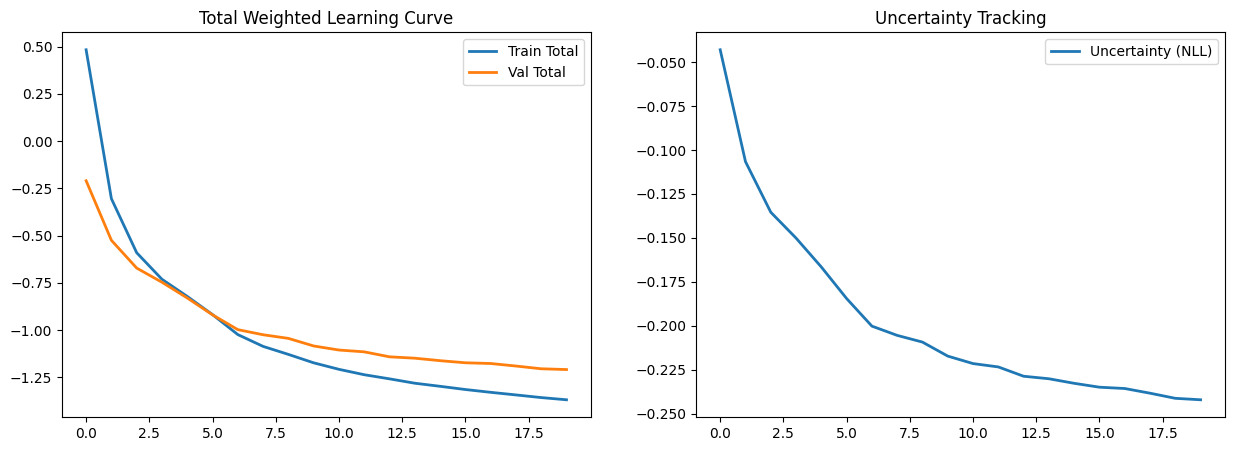

In [ ]:
# # Check for existing checkpoints and load the latest one
# checkpoint_files = sorted(SAVE_DIR.glob('cerebra_probabilistic_best.pth'), key=os.path.getmtime)

# if checkpoint_files:
#     latest_checkpoint = checkpoint_files[-1]
#     print(f"Loading checkpoint from {latest_checkpoint}")
#     checkpoint = torch.load(latest_checkpoint, map_location=device, weights_only=False)
#     encoder.load_state_dict(checkpoint['encoder_state_dict'])
#     decoder.load_state_dict(checkpoint['decoder_state_dict'])
#     best_val_loss = checkpoint.get('best_val_loss', float('inf'))
#     print(f"Resuming training with best_val_loss: {best_val_loss:.4f}")
# else:
#     print("No checkpoint found. Starting training from scratch.")

history = train_and_visualize(encoder, decoder, train_loader, val_loader, best_val_loss=best_val_loss)

In [ ]:
# Keep only the two latest full checkpoints.
checkpoint_files = sorted(
    SAVE_DIR.glob("cerebra_probabilistic_best.pth"),
    key=os.path.getmtime,
)

checkpoint = {
    "encoder_state_dict": encoder.state_dict(),
    "decoder_state_dict": decoder.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_val_loss": best_val_loss,
    "epoch": epoch + 1,
    "lr": lr,
}

if full_dataset is not None:
    checkpoint["mean"] = full_dataset.mean
    checkpoint["std"] = full_dataset.std
    checkpoint["input_dim"] = full_dataset.data_standardized.shape[1]

torch.save(
    checkpoint,
    f"{SAVE_DIR}/cerebra_probabilistic_best.pth",
)


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.amp import autocast

# Use the same collate function you used for train/val loaders
def fmri_collate_fn(batch):
    clean = torch.stack([item[0] for item in batch], dim=0)
    noisy = torch.stack([item[1] for item in batch], dim=0)
    labels = [item[2] for item in batch]  # keep metadata as normal Python dicts
    return clean, noisy, labels


def run_final_test(
    encoder,
    decoder,
    test_dataset_subset,
    noise_std_devs=[0.0, 0.1, 0.2, 0.3, 0.4],
    save_dir=None,
    batch_size=32, # Increased batch size for efficiency
    num_workers=2, # Increased workers for faster data loading
):
    encoder.eval()
    decoder.eval()

    all_test_nll_scores = {}
    all_examples = {}

    print("Evaluating Probabilistic Cerebra Pipeline with varying noise levels...")

    for noise_std_dev in noise_std_devs:
        print(f"\n--- Testing with Noise Standard Deviation: {noise_std_dev} ---")

        # Save current dataset noise level, then temporarily override it
        original_noise_std_dev = test_dataset_subset.dataset.noise_std_dev
        test_dataset_subset.dataset.set_noise_std_dev(noise_std_dev)

        test_loader = DataLoader(
            test_dataset_subset,
            batch_size=batch_size,
            shuffle=False,
            pin_memory=True,
            num_workers=num_workers, # Use multiple workers
            collate_fn=fmri_collate_fn,
        )

        test_nll_scores = []
        examples_for_this_noise = []

        # Collect all predictions for the current noise level first
        all_clean_tensors = []
        all_noisy_tensors = []
        all_mean_tensors = []
        all_ci_tensors = []
        all_labels_list = []

        with torch.no_grad():
            for clean, noisy, labels in test_loader:
                clean = clean.to(device, non_blocking=True).float()
                noisy = noisy.to(device, non_blocking=True).float()

                with autocast("cuda", dtype=torch.bfloat16):
                    latent = encoder(noisy)
                    mean, logvar = decoder(latent)

                    nll = uncertainty_loss(mean, logvar, clean)

                test_nll_scores.extend(nll.cpu().numpy()) # Store NLL values

                all_clean_tensors.append(clean.float().cpu())
                all_noisy_tensors.append(noisy.float().cpu())
                all_mean_tensors.append(mean.float().cpu())
                std = torch.exp(0.5 * logvar)
                ci_bound = 1.96 * std
                all_ci_tensors.append(ci_bound.float().cpu())
                all_labels_list.extend(labels)

        # Concatenate collected tensors and then convert to numpy for visualization
        concatenated_clean = torch.cat(all_clean_tensors, dim=0).numpy()
        concatenated_noisy = torch.cat(all_noisy_tensors, dim=0).numpy()
        concatenated_mean = torch.cat(all_mean_tensors, dim=0).numpy()
        concatenated_ci = torch.cat(all_ci_tensors, dim=0).numpy()

        # Save a few examples for visualization (first 3 from the concatenated array)
        for i in range(min(3, len(all_labels_list))):
            examples_for_this_noise.append({
                "clean": concatenated_clean[i].squeeze(),
                "noisy": concatenated_noisy[i].squeeze(),
                "mean": concatenated_mean[i].squeeze(),
                "ci": concatenated_ci[i].squeeze(),
                "label": all_labels_list[i],   # optional metadata
            })

        all_test_nll_scores[noise_std_dev] = test_nll_scores
        all_examples[noise_std_dev] = examples_for_this_noise

        # Restore original dataset noise level
        test_dataset_subset.dataset.set_noise_std_dev(original_noise_std_dev)

    # --- PLOT 1: PROBABILISTIC RECOVERY ---
    for noise_std_dev, examples in all_examples.items():
        if not examples:
            continue

        fig, axes = plt.subplots(len(examples), 1, figsize=(15, 4 * len(examples)))
        if len(examples) == 1:
            axes = [axes]

        for idx, ex in enumerate(examples):
            feature_dim = len(ex["clean"])

            # safer slice for visualization
            start = min(5000, max(0, feature_dim - 300))
            end = min(start + 300, feature_dim)

            x = np.arange(end - start)

            axes[idx].plot(
                x,
                ex["clean"][start:end],
                label="Ground Truth",
                alpha=0.7
            )

            axes[idx].scatter(
                x,
                ex["noisy"][start:end],
                label=f"Noisy Input (std={noise_std_dev})",
                s=4,
                alpha=0.25
            )

            axes[idx].plot(
                x,
                ex["mean"][start:end],
                label="Recovered Mean",
                lw=1.5
            )

            axes[idx].fill_between(
                x,
                ex["mean"][start:end] - ex["ci"][start:end],
                ex["mean"][start:end] + ex["ci"][start:end],
                alpha=0.2,
                label="95% Confidence Interval"
            )

            title = f"Trial {idx+1}: Probabilistic Recovery (noise std={noise_std_dev})"

            # If you want, include session info from metadata
            if isinstance(ex["label"], dict) and "session" in ex["label"]:
                title += f" | session={ex['label']['session']}"

            axes[idx].set_title(title)
            axes[idx].legend(loc="upper right", fontsize="small", ncol=2)

        plt.tight_layout()

        if save_dir is not None:
            plt.savefig(
                f"{save_dir}/probabilistic_test_results_noise_{str(noise_std_dev).replace('.', '_')}.png",
                dpi=200,
                bbox_inches="tight"
            )

        plt.show()

    # --- PLOT 2: NLL DISTRIBUTIONS ---
    plt.figure(figsize=(10, 6))

    for noise_std_dev, scores in all_test_nll_scores.items():
        if not scores:
            continue

        scores = np.array(scores)

        plt.hist(
            scores,
            bins=15,
            alpha=0.5,
            label=f"Noise std={noise_std_dev}",
            edgecolor="black"
        )

        plt.axvline(
            np.mean(scores),
            linestyle="dashed",
            alpha=0.8,
            label=f"Mean NLL @ {noise_std_dev}: {np.mean(scores):.4f}"
        )

    plt.title("System Confidence Distribution (NLL) Across Noise Levels")
    plt.xlabel("Negative Log-Likelihood (Lower is better)")
    plt.ylabel("Trial Frequency")
    plt.legend()
    plt.show()

    # --- PRINT SUMMARY ---
    for noise_std_dev, scores in all_test_nll_scores.items():
        if len(scores) > 0:
            print(
                f"Testing complete for noise std={noise_std_dev}. "
                f"Mean NLL: {np.mean(scores):.6f}"
            )

    return all_test_nll_scores, all_examples

Evaluating Probabilistic Cerebra Pipeline with varying noise levels...

--- Testing with Noise Standard Deviation: 0.0 ---
Noise standard deviation updated to: 0.0
Noise standard deviation updated to: 0.2

--- Testing with Noise Standard Deviation: 0.1 ---
Noise standard deviation updated to: 0.1
Noise standard deviation updated to: 0.2

--- Testing with Noise Standard Deviation: 0.2 ---
Noise standard deviation updated to: 0.2
Noise standard deviation updated to: 0.2

--- Testing with Noise Standard Deviation: 0.3 ---
Noise standard deviation updated to: 0.3
Noise standard deviation updated to: 0.2

--- Testing with Noise Standard Deviation: 0.4 ---
Noise standard deviation updated to: 0.4
Noise standard deviation updated to: 0.2


KeyboardInterrupt: 

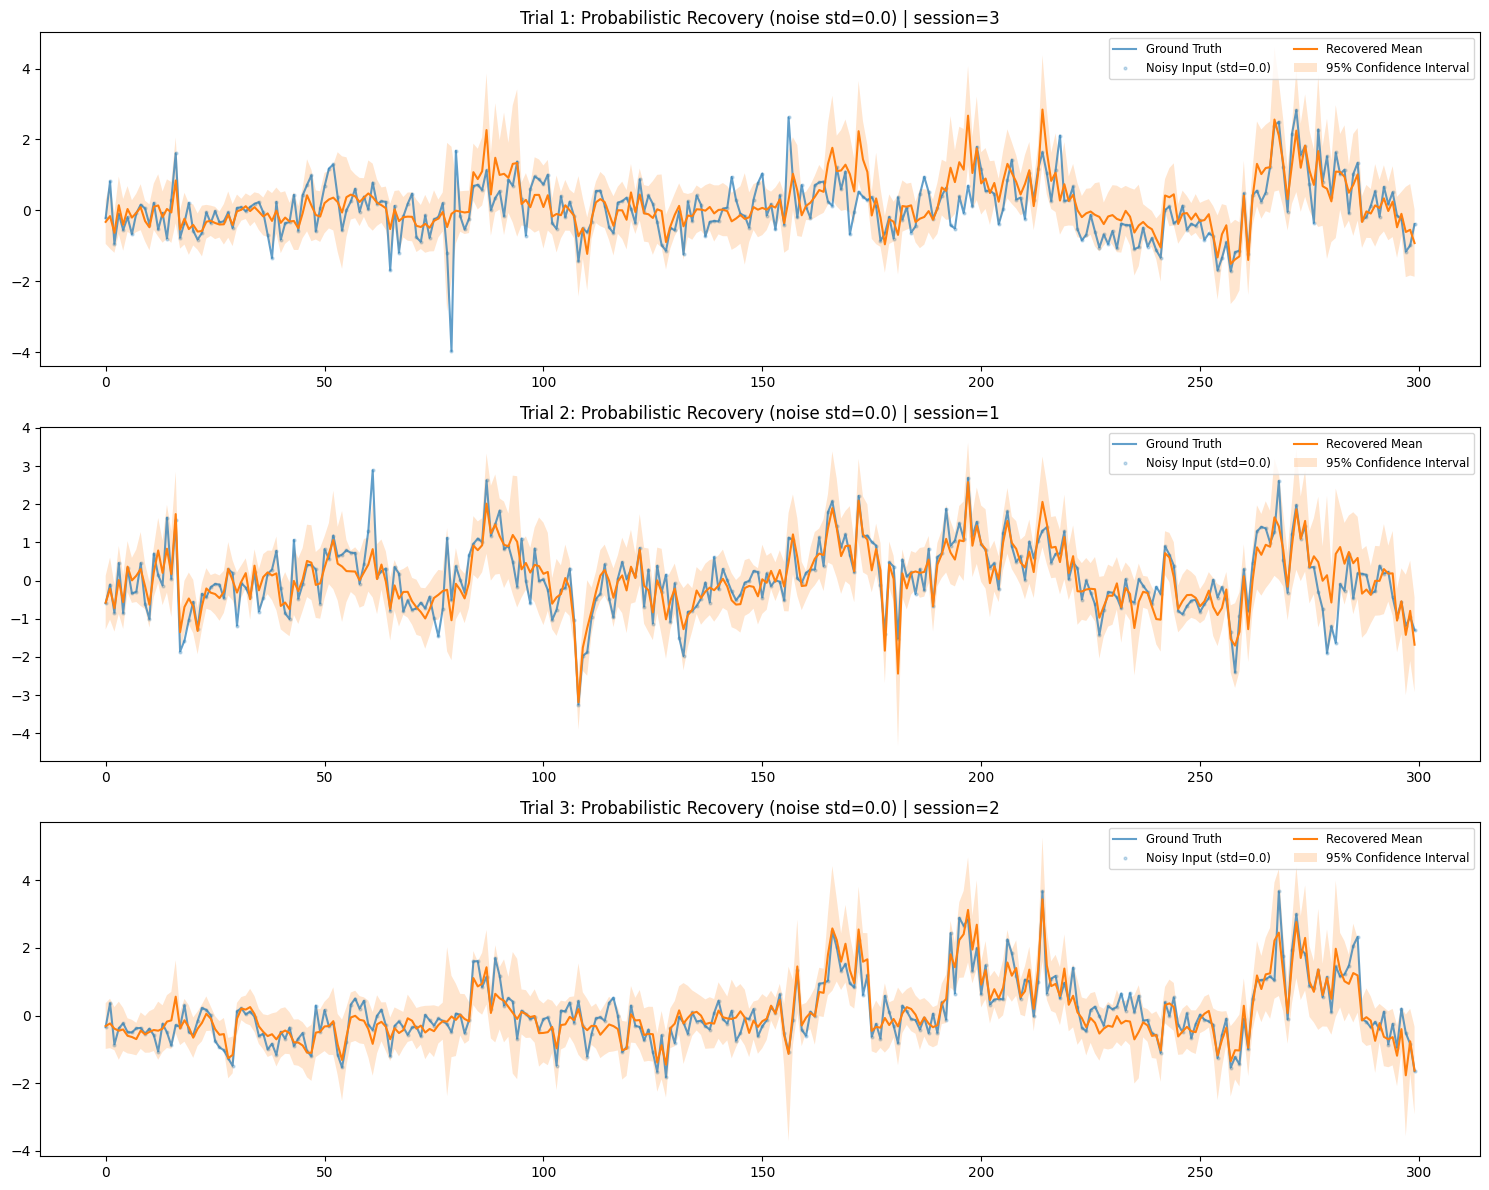

In [ ]:
all_test_nll_scores, all_examples = run_final_test(
    encoder=encoder,
    decoder=decoder,
    test_dataset_subset=test_dataset,
    noise_std_devs=[0.0, 0.1, 0.2, 0.3, 0.4],
    save_dir=SAVE_DIR,
)

Now, let's visualize the *latent dimensions* from the `encoder` using t-SNE. This will show how the model arranges different brain states in a low-dimensional space based on the learned representations.

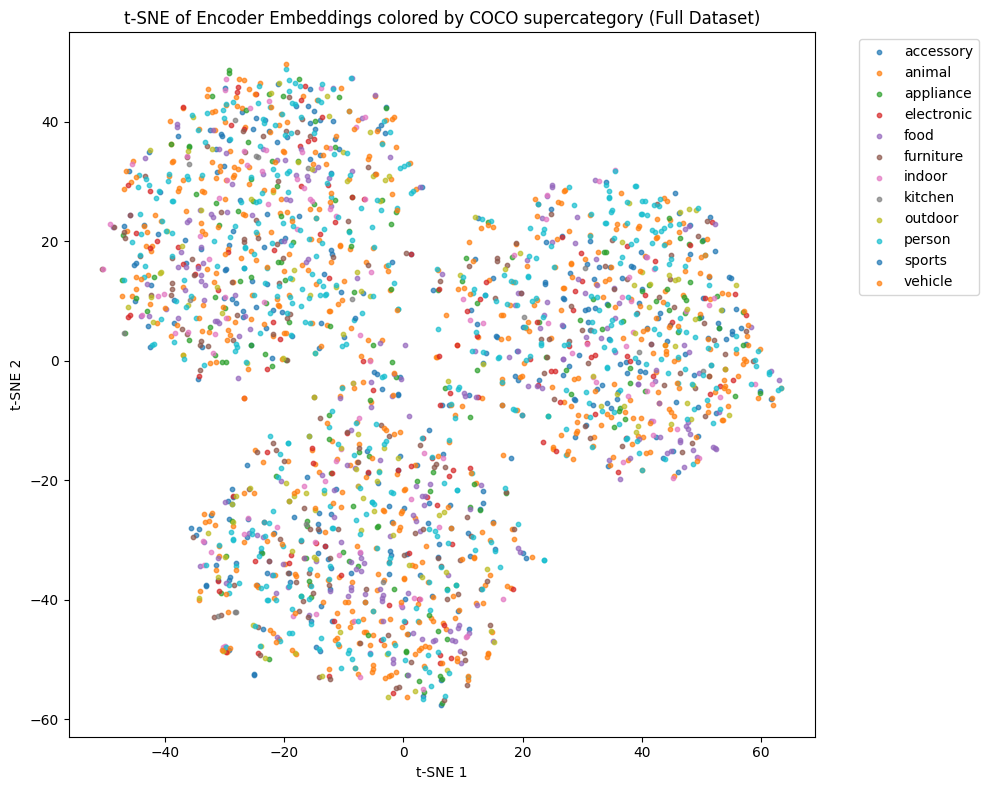

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torch.amp import autocast
from torch.utils.data import DataLoader

def extract_embeddings_and_metadata(encoder, loader, device):
    encoder.eval()
    all_embeddings = []
    all_metadata = []

    with torch.no_grad():
        for clean, noisy, labels in loader:
            clean = clean.to(device).float()

            with autocast("cuda", dtype=torch.bfloat16):
                z = encoder(clean)

            all_embeddings.append(z.float().cpu().numpy())
            all_metadata.extend(labels)

    return np.vstack(all_embeddings), all_metadata


# Define full_data_loader here to ensure it's available
full_data_loader = DataLoader(
    full_dataset,
    batch_size=32, # Can use a larger batch size for inference
    shuffle=False,
    pin_memory=True,
    num_workers=2,
    collate_fn=fmri_collate_fn,
)

# 1. Extract embeddings
# Modifying this line to use full_data_loader instead of test_loader
Z, metadata = extract_embeddings_and_metadata(encoder, full_data_loader, device)

# 2. Choose labels
labels = []
for m in metadata:
    supercats = m["object_supercategories"]
    if len(supercats) == 0:
        labels.append("no_supercategory")
    else:
        labels.append(supercats[0])

labels = np.array(labels)

# 3. t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)
Z_2d = tsne.fit_transform(Z)

# 4. Plot
plt.figure(figsize=(10, 8))

for label in np.unique(labels):
    idx = labels == label
    plt.scatter(
        Z_2d[idx, 0],
        Z_2d[idx, 1],
        s=10,
        alpha=0.7,
        label=label
    )

plt.title("t-SNE of Encoder Embeddings colored by COCO supercategory (Full Dataset)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Denoised Veriyi Web İçin Hazırlama

Modelinizin `decoder`'ından elde ettiğiniz `mean` (ortalama) çıktısı, denoise edilmiş beyin aktivasyon verilerinizdir. Bu veriyi bir web sitesinde kullanmak için genellikle `JSON` formatına çevirip kaydetmek en yaygın yöntemdir. Aşağıdaki kod bloğu, bu `mean` verisini (örnek olarak oluşturulmuş) `JSON` formatında bir dosyaya kaydetmenizi sağlar. Gerçek uygulamada, `mean_output` değişkeni yerine `decoder`'ınızdan gelen gerçek çıktıyı kullanmanız gerekecek.

In [ ]:
import json
import numpy as np
from pathlib import Path

# Gerçek uygulamada, bu kısım decoder'ınızdan gelen 'mean' çıktısı olacaktır.
# Örneğin, run_final_test fonksiyonunda 'mean' değişkeninin içeriği.
# Burada bir simülasyon yapıyoruz:
# Normalde, mean.shape (batch_size, input_dim) gibi olacaktır.
# Bizim input_dim'imiz 327684, bu yüzden tek bir örnek için bu boyutta bir array simüle ediyoruz.
simulated_mean_output = np.random.rand(327684).astype(np.float32)

# Veriyi Python listesine dönüştürün (JSON için uygun format)
mean_data_list = simulated_mean_output.tolist()

# Kaydedilecek dosya yolu
output_dir = Path("/content/web_data")
output_dir.mkdir(exist_ok=True)
denoised_data_filepath = output_dir / "denoised_brain_activity.json"

# JSON dosyasına kaydet
with open(denoised_data_filepath, 'w') as f:
    json.dump(mean_data_list, f)

print(f"Denoise edilmiş beyin aktivasyon verisi kaydedildi: {denoised_data_filepath}")
print(f"Dosyanın boyutu: {denoised_data_filepath.stat().st_size / (1024*1024):.2f} MB")

# İsteğe bağlı: Dosyayı indirmek için bir link oluştur
from google.colab import files
files.download(denoised_data_filepath)


Bu `denoised_brain_activity.json` dosyasını indirdikten sonra, web sitenizde kullanabilirsiniz. Şimdi basit bir HTML/JavaScript yapısı ile bu veriyi Three.js kullanarak nasıl görselleştirebileceğinize dair genel bir şablon sağlayabilirim. Bu kod Colab'da çalışmayacak, ancak bir metin dosyasına kaydedip tarayıcınızda açarak test edebilirsiniz.

```html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>3D Brain Activity Viewer</title>
    <style>
        body { margin: 0; overflow: hidden; font-family: sans-serif; }
        #info { position: absolute; top: 10px; width: 100%; text-align: center; z-index: 100; color: white; }
        canvas { display: block; }
    </style>
</head>
<body>
    <div id="info">Loading Brain Model...</div>
    <script src="https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/three@0.128.0/examples/js/controls/OrbitControls.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/three@0.128.0/examples/js/loaders/OBJLoader.js"></script>
    
    <script>
        let scene, camera, renderer, brainMesh, controls;
        let denoisedData = [];

        // Color mapping function (blue for low activity, red for high)
        function getColorForActivity(activityValue) {
            const minVal = 0; // Assuming normalized activity 0-1
            const maxVal = 1;
            const normalized = (activityValue - minVal) / (maxVal - minVal);
            
            // Interpolate between blue (0,0,1) and red (1,0,0)
            const r = normalized;
            const b = 1 - normalized;
            return new THREE.Color(r, 0, b);
        }

        async function init() {
            // 1. Scene setup
            scene = new THREE.Scene();
            scene.background = new THREE.Color(0x333333);

            // 2. Camera setup
            camera = new THREE.PerspectiveCamera(75, window.innerWidth / window.innerHeight, 0.1, 1000);
            camera.position.z = 200;

            // 3. Renderer setup
            renderer = new THREE.WebGLRenderer({ antialias: true });
            renderer.setSize(window.innerWidth, window.innerHeight);
            document.body.appendChild(renderer.domElement);

            // 4. Lighting
            const ambientLight = new THREE.AmbientLight(0xffffff, 0.7);
            scene.add(ambientLight);
            const directionalLight = new THREE.DirectionalLight(0xffffff, 0.5);
            directionalLight.position.set(0, 1, 1).normalize();
            scene.add(directionalLight);

            // 5. OrbitControls
            controls = new THREE.OrbitControls(camera, renderer.domElement);
            controls.enableDamping = true; // smooth camera movement
            controls.dampingFactor = 0.25;

            // 6. Load Data (Denoised Brain Activity)
            try {
                const response = await fetch('./denoised_brain_activity.json'); // Make sure this path is correct!
                denoisedData = await response.json();
                document.getElementById('info').textContent = 'Loading Brain Model...';
            } catch (error) {
                document.getElementById('info').textContent = 'Error loading denoised data: ' + error.message;
                console.error('Error loading denoised_brain_activity.json:', error);
                return;
            }

            // 7. Load 3D Brain Model (e.g., fsaverage.obj - you'll need to provide this file)
            // You'll need to get an OBJ file for fsaverage (or similar) and place it next to this HTML file
            const objLoader = new THREE.OBJLoader();
            objLoader.load(
                './fsaverage.obj', // <<< You need to provide this OBJ file
                function (object) {
                    object.traverse(function (child) {
                        if (child instanceof THREE.Mesh) {
                            brainMesh = child;
                            // Apply a basic material initially
                            brainMesh.material = new THREE.MeshPhongMaterial({ color: 0xaaaaaa, specular: 0x111111, shininess: 30, vertexColors: true });
                            
                            // Check if denoised data matches mesh vertex count
                            if (denoisedData.length > 0 && brainMesh.geometry.attributes.position.count === denoisedData.length) {
                                const colors = [];
                                for (let i = 0; i < denoisedData.length; i++) {
                                    const color = getColorForActivity(denoisedData[i]);
                                    colors.push(color.r, color.g, color.b);
                                }
                                brainMesh.geometry.setAttribute('color', new THREE.Float32BufferAttribute(colors, 3));
                                document.getElementById('info').textContent = '3D Brain Model Loaded with Activity Data.';
                            } else if (denoisedData.length > 0) {
                                document.getElementById('info').textContent = 'Warning: Data length mismatch with brain model vertices. Showing default color.';
                                console.warn('Denoised data length (' + denoisedData.length + ') does not match brain mesh vertex count (' + brainMesh.geometry.attributes.position.count + ').');
                            } else {
                                document.getElementById('info').textContent = 'No denoised data loaded. Showing default color.';
                            }
                        }
                    });
                    scene.add(object);
                },
                function (xhr) {
                    console.log((xhr.loaded / xhr.total * 100) + '% loaded');
                },
                function (error) {
                    document.getElementById('info').textContent = 'Error loading 3D model: ' + error.message;
                    console.error('An error happened loading OBJ:', error);
                }
            );

            animate();
        }

        function animate() {
            requestAnimationFrame(animate);
            controls.update(); // only required if controls.enableDamping or controls.autoRotate are set to true
            renderer.render(scene, camera);
        }

        function onWindowResize() {
            camera.aspect = window.innerWidth / window.innerHeight;
            camera.updateProjectionMatrix();
            renderer.setSize(window.innerWidth, window.innerHeight);
        }

        window.addEventListener('resize', onWindowResize, false);
        init();
    </script>
</body>
</html>
```

**Bu Şablonu Kullanmak İçin Yapmanız Gerekenler:**

1.  **`denoised_brain_activity.json` dosyasını indirin.** Yukarıdaki Colab kodu çalıştığında otomatik olarak indirilmelidir.
2.  **`fsaverage.obj` dosyasını edinin.** Bu dosyayı FreeSurfer gibi araçlar kullanarak veya nörogörüntüleme kaynaklarından (örneğin, OpenNeuro veya Brainstorm topluluğu) temin etmeniz gerekecek. `fsaverage` bir standart beyin atlasıdır ve 3D modeli kolayca bulunabilir.
3.  Yukarıdaki HTML kodunu bir metin düzenleyiciye kopyalayın ve **`index.html`** olarak kaydedin.
4.  `denoised_brain_activity.json` ve `fsaverage.obj` dosyalarını `index.html` dosyasının yanına, aynı dizine yerleştirin.
5.  `index.html` dosyasını web tarayıcınızda açın.

Bu şablon, `fsaverage.obj` modelini yükleyecek ve `denoised_brain_activity.json` dosyasındaki verileri kullanarak modelin vertex'lerini aktivasyon değerlerine göre renklendirecektir. Mavi düşük aktiviteyi, kırmızı ise yüksek aktiviteyi temsil edecektir. OrbitControls sayesinde modeli fare ile döndürebilir ve yakınlaştırabilirsiniz.